# Network Statistics

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from common import *
from typing import List, Optional
from collections import defaultdict
from experiment import NetworkSetting
from data.http import HTTPExperiment, PlottableDataPoint
from data.media import MediaExperiment
from treatments.picoquic import treatment_map as http_treatment_map
from treatments.media import treatment_map as media_treatment_map
from treatments.network_settings import *

## Parse data

In [2]:
http_network_setting = NETWORK_SETTING_WIFI
media_network_setting = NETWORK_SETTING_SAT

In [3]:
default_ifaces = ['h1-eth0', 'p1-eth0', 'p1-eth1', 'h2-eth0']
default_metrics = ['tx_packets', 'tx_bytes', 'rx_packets', 'rx_bytes']
def merge_iface_data(my_ifaces, my_metrics, ifaces=default_ifaces):
    data = {}
    for iface, metric in zip(my_ifaces, my_metrics):
        data[iface] = metric
    ys = []
    if 'p0-eth1' in data:
        assert data['h1-eth0'] <= data['p0-eth1']
        data['h1-eth0'] = data['p0-eth1']
    for iface in ifaces:
        ys.append(data[iface])
    return ys

In [4]:
# HTTP benchmark
def parse_http_data(labels, num_trials=1, network_setting=http_network_setting, execute=False, normalized=False):
    bottleneck_bw = min(network_setting.get('bw1'), network_setting.get('bw2'))
    data_size = 125000 * bottleneck_bw * 10 # 125000 * bottleneck_bw * time_s
    treatments = [http_treatment_map(label) for label in labels]
    exp = HTTPExperiment(num_trials=num_trials, treatments=treatments, network_settings=[network_setting], data_sizes=[data_size])
    http_raw_data = exp.to_raw_data(execute=execute)
    
    # Create plottable data
    http_data = {}
    for label in labels:
        outputs = http_raw_data.data[label][network_setting.label()][data_size]
        outputs = filter(lambda output: output.get('success'), outputs)
        outputs = list(map(lambda output: (output['time_s'], output['statistics']), outputs))
        data = defaultdict(lambda: defaultdict(lambda: []))
        for time_s, stats in outputs:
            for metric in default_metrics:
                values = merge_iface_data(stats['ifaces'], stats[metric], ifaces=default_ifaces)
                if normalized:
                    values = [y / time_s for y in values]
                if 'bytes' in metric:
                    values = [y / 1000000 for y in values]
                for iface, value in zip(default_ifaces, values):
                    data[iface][metric].append(value)
        for iface in default_ifaces:
            for metric in default_metrics:
                data[iface][metric] = PlottableDataPoint(data[iface][metric])
        http_data[label] = data
    return http_data

In [5]:
# Media benchmark
def parse_media_data(labels, duration=300, network_setting=media_network_setting, execute=False, normalized=True):
    treatments = [media_treatment_map(label) for label in labels]
    exp = MediaExperiment(duration, treatments, network_setting)
    media_raw_data = exp.to_raw_data(execute=execute)

    # Create plottable data
    media_data = {}
    for label in labels:
        output = media_raw_data.data[label]
        assert output.get('success')
        data = defaultdict(lambda: {})
        stats = output['statistics']
        for metric in default_metrics:
            values = merge_iface_data(stats['ifaces'], stats[metric], ifaces=default_ifaces)
            if normalized:
                values = [y / output['time_s'] for y in values]
            if 'bytes' in metric:
                values = [y / 1000 for y in values]
            for iface, value in zip(default_ifaces, values):
                data[iface][metric] = PlottableDataPoint([value])
        media_data[label] = data
    return media_data

## Plotting Functions

In [7]:
def plot_network_statistics(data, keys: List[str], metric: str, title: str=None, plot_yerr=True, ylabel=None, ylim=0, pdf: Optional[str]=None, delta=25, style=False, legend=False):
    # Default ifaces
    ifaces = ['h1-eth0', 'p1-eth0', 'p1-eth1', 'h2-eth0']
    xticklabels = ['Client→', '←Proxy', 'Proxy→', '←Server']
    
    # Example data
    x = np.arange(len(ifaces))  # the label locations
    width = 1.0 / (len(keys) + 1)  # the width of the bars

    # Create plot
    fig, ax = plt.subplots(figsize=(3.5,2))
    labels = []
    for i, key in enumerate(keys):
        ys_raw = [data[key][iface][metric] for iface in ifaces]
        ys = [y.p(50) for y in ys_raw]
        print(key, metric, ys)
        if plot_yerr:
            yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
            yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
            yerr = (yerr_lower, yerr_upper)
        else:
            yerr = None
        if style:
            label = LABEL_MAP[key]
            sty = STYLE[label]
            ax.bar(x + width * (i - len(keys) / 2 + 0.5), ys, width, yerr=yerr, capsize=5, label=label, color=sty.color)
        else:
            label = key
            ax.bar(x + width * (i - len(keys) / 2 + 0.5), ys, width, yerr=yerr, capsize=5, label=label)
        labels.append(label)
    
    # Add labels, title
    if ylabel:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel(f'{metric} / sec')
    if title:
        ax.set_title(f'{title} ({metric})')
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    ax.set_ylim(ylim)

    # Add legend
    ncol = 3
    legend_height = 1.4
    legend_height += 0.06 * (math.ceil(len(keys) / ncol) - 1)
    if legend:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, legend_height), ncol=ncol)
    plt.grid(axis='y')
    
    # Show plot
    if pdf:
        save_pdf(pdf)
    plt.show()

## HTTP Benchmark

picoquic tx_bytes [0.323505, 27.475927, 0.18614, 27.721608500000002]
picoquic_rtunnel_retx7_ordered32 tx_bytes [1.4292155000000002, 34.8920145, 0.10316449999999999, 27.6406415]
picoquic_rtunnel_retx7 tx_bytes [1.462369, 35.415855, 0.1131845, 27.859173]
picoquic_iblt_20ms tx_bytes [4.824539, 27.670078, 0.112891, 26.715448]
picoquic_iblt_20ms_hint tx_bytes [0.386548, 27.498716, 0.1077205, 27.509586]
../figures/network_stats_http_tx_bytes_legend.pdf


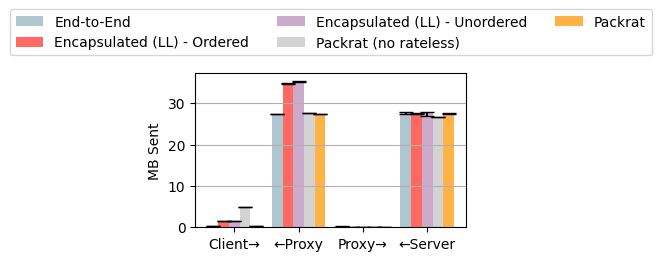

picoquic tx_bytes [0.323505, 27.475927, 0.18614, 27.721608500000002]
picoquic_rtunnel_retx7_ordered32 tx_bytes [1.4292155000000002, 34.8920145, 0.10316449999999999, 27.6406415]
picoquic_rtunnel_retx7 tx_bytes [1.462369, 35.415855, 0.1131845, 27.859173]
picoquic_iblt_20ms tx_bytes [4.824539, 27.670078, 0.112891, 26.715448]
picoquic_iblt_20ms_hint tx_bytes [0.386548, 27.498716, 0.1077205, 27.509586]
../figures/network_stats_http_tx_bytes.pdf


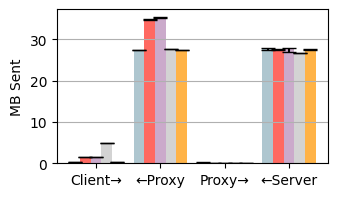

picoquic tx_packets [3591.5, 18615.5, 1893.5, 18737.0]
picoquic_rtunnel_retx7_ordered32 tx_packets [26297.5, 27306.5, 1025.5, 21376.5]
picoquic_rtunnel_retx7 tx_packets [26769.5, 27813.0, 1117.0, 21546.0]
picoquic_iblt_20ms tx_packets [6649.0, 21404.0, 1076.5, 20656.0]
picoquic_iblt_20ms_hint tx_packets [2241.5, 18641.5, 1064.0, 18632.0]
../figures/network_stats_http_tx_packets.pdf


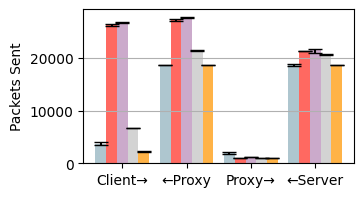

In [25]:
# 3. Sending with hint reduces tx_bytes (keeps perf).
# wifi has tremendous link overheads
# sidekick reduces total number of packets because connection is faster
normalized = False
labels = [
    'picoquic',
    'picoquic_rtunnel_retx7_ordered32',
    'picoquic_rtunnel_retx7',
    f'picoquic_iblt_{ACK_DELAY_WIFI}ms',
    f'picoquic_iblt_{ACK_DELAY_WIFI}ms_hint',
]
http_data = parse_http_data(num_trials=20, labels=labels, normalized=normalized, execute=True)
plot_network_statistics(http_data, labels, 'tx_bytes', ylabel='MB Sent', ylim=0, pdf='../figures/network_stats_http_tx_bytes_legend.pdf', style=True, legend=True)
plot_network_statistics(http_data, labels, 'tx_bytes', ylabel='MB Sent', ylim=0, pdf='../figures/network_stats_http_tx_bytes.pdf', style=True) 
plot_network_statistics(http_data, labels, 'tx_packets', ylabel='Packets Sent', ylim=0, pdf='../figures/network_stats_http_tx_packets.pdf', style=True)

## Media Benchmark

baseline tx_bytes [0.22252211688557333, 14.429396536354558, 0.21154111124219127, 14.42251606793728]
baseline_rtunnel_retx7_ordered32 tx_bytes [3.484240834685545, 21.428788316511838, 0.17026774063824976, 14.243995704005718]
baseline_rtunnel_retx7 tx_bytes [3.526687382660099, 21.754121024960092, 0.1996598284891216, 14.380168581543042]
iblt_delay60_hint_nack tx_bytes [1.094166638664296, 16.002943795700038, 0.3723072985405006, 14.28015832847227]
iblt_delay60 tx_bytes [6.491432415938016, 16.286976860163964, 0.46800994368004595, 14.314696799455687]
../figures/network_stats_media_legend.pdf


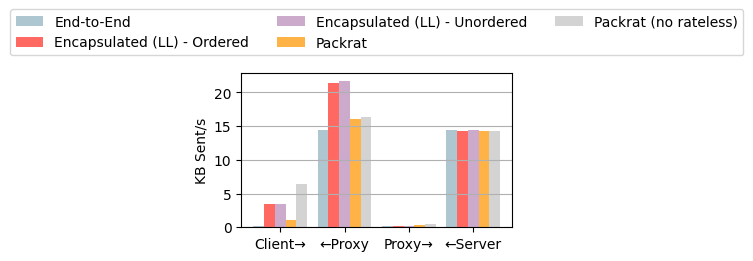

baseline tx_bytes [0.22252211688557333, 14.429396536354558, 0.21154111124219127, 14.42251606793728]
baseline_rtunnel_retx7_ordered32 tx_bytes [3.484240834685545, 21.428788316511838, 0.17026774063824976, 14.243995704005718]
baseline_rtunnel_retx7 tx_bytes [3.526687382660099, 21.754121024960092, 0.1996598284891216, 14.380168581543042]
iblt_delay60_hint_nack tx_bytes [1.094166638664296, 16.002943795700038, 0.3723072985405006, 14.28015832847227]
iblt_delay60 tx_bytes [6.491432415938016, 16.286976860163964, 0.46800994368004595, 14.314696799455687]
../figures/network_stats_media_tx_bytes.pdf


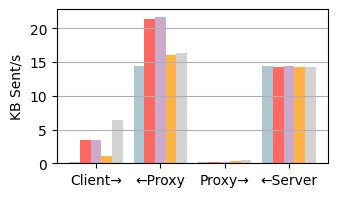

baseline tx_packets [1.359447388897725, 51.26503847357584, 1.3816424483083, 51.17625823593354]
baseline_rtunnel_retx7_ordered32 tx_packets [62.49513011824959, 69.02596276933542, 0.693588854193483, 50.543206982787495]
baseline_rtunnel_retx7 tx_packets [63.46633460963712, 70.35230429407144, 1.1541351284144536, 51.02608961970825]
iblt_delay60_hint_nack tx_packets [6.702840869130596, 57.212741888746336, 1.9143047184189201, 50.65971617149201]
iblt_delay60 tx_packets [26.044940907124477, 57.88257851366053, 2.02522442077129, 50.78597020087566]
../figures/network_stats_media_tx_packets.pdf


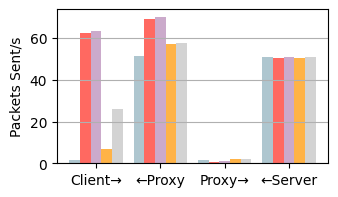

In [9]:
# wifi has tremendous link overheads
# 3. Sending with hint reduces tx_bytes (keeps perf).
# 2. Sending with nack reduces tx_packets (keeps perf).
execute = True
duration = 180

def gen_labels():
    labels = [
        'baseline',
        'baseline_rtunnel_retx7_ordered32',
        'baseline_rtunnel_retx7',
        f'iblt_delay{ACK_DELAY_SAT}_hint_nack',
        f'iblt_delay{ACK_DELAY_SAT}',
    ]
    return labels

media_data = parse_media_data(execute=execute, duration=duration, labels=gen_labels())
plot_network_statistics(media_data, gen_labels(), 'tx_bytes', ylabel='KB Sent/s', pdf='../figures/network_stats_media_legend.pdf', style=True, plot_yerr=False, legend=True)
plot_network_statistics(media_data, gen_labels(), 'tx_bytes', ylabel='KB Sent/s', pdf='../figures/network_stats_media_tx_bytes.pdf', style=True, plot_yerr=False)
plot_network_statistics(media_data, gen_labels(), 'tx_packets', ylabel='Packets Sent/s', pdf='../figures/network_stats_media_tx_packets.pdf', style=True, plot_yerr=False)